# Task 2: Baseline Modeling — Traditional Machine Learning

**Project:** Domain-Adaptive Sentiment & Public Opinion Analysis using Transformers and LLMs  
**Task:** Establish baseline performance using classical ML models (Logistic Regression, SVM, Naïve Bayes) with TF-IDF features.

## Experimental Framework (A / B / C)

| Model | Training Data | Testing Data | Purpose |
|-------|--------------|--------------|-------|
| **Model A** | GoEmotions (General only) | FPB Test | Measure zero-shot domain transfer |
| **Model B** | FPB Train (Domain only) | FPB Test | Measure performance on limited domain data |
| **Model C** | GoEmotions + FPB Train (Mixed) | FPB Test | Evaluate combined dataset benefit |

**Architecture is identical across A/B/C — only the training data changes.**

## 1. Setup & Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import ComplementNB
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay,
    f1_score, precision_score, recall_score
)

import re, string

plt.rcParams['figure.dpi'] = 120
sns.set_theme(style='whitegrid', palette='muted')

print('All imports successful!')

All imports successful!


## 2. Load Datasets

In [2]:
# Adjust BASE path if running locally (set to folder containing the CSVs)
BASE = './'

goemotions = pd.read_csv(BASE + 'goemotions_5class.csv')   # General domain
fpb_train  = pd.read_csv(BASE + 'fpb_train.csv')           # FPB train split
fpb_val    = pd.read_csv(BASE + 'fpb_val.csv')             # FPB validation split
fpb_test   = pd.read_csv(BASE + 'fpb_test.csv')            # FPB test split (evaluation target)

print('Dataset Sizes')
print('=' * 45)
print(f'GoEmotions (general):  {len(goemotions):>6,} rows')
print(f'FPB train (domain):    {len(fpb_train):>6,} rows')
print(f'FPB val:               {len(fpb_val):>6,} rows')
print(f'FPB test:              {len(fpb_test):>6,} rows')

Dataset Sizes
GoEmotions (general):  43,404 rows
FPB train (domain):     3,392 rows
FPB val:                  727 rows
FPB test:                 727 rows


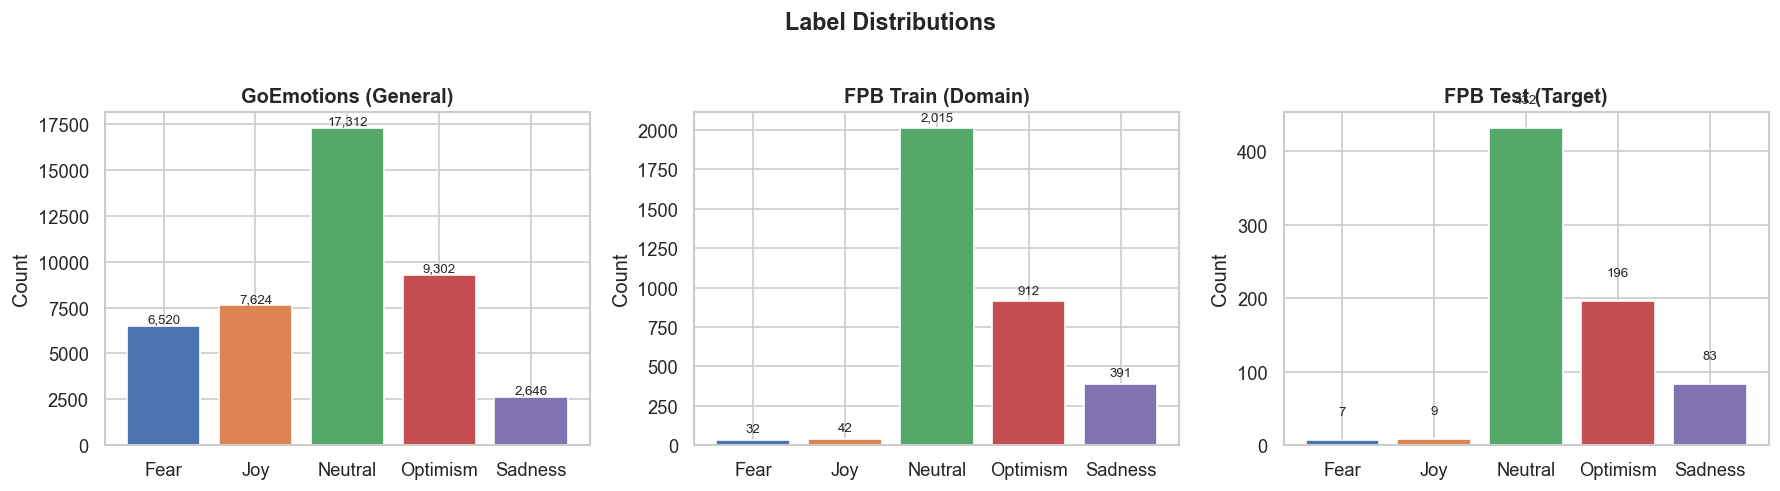

Note: FPB has severe class imbalance — very few Joy/Fear samples.


In [3]:
# Label distribution visualisation
# Alphabetical order matches sklearn's internal class ordering
# (prevents target_names misalignment in classification_report)
LABELS = ['Fear', 'Joy', 'Neutral', 'Optimism', 'Sadness']
colors = ['#4C72B0', '#DD8452', '#55A868', '#C44E52', '#8172B2']

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
datasets = [
    (goemotions, 'GoEmotions (General)'),
    (fpb_train,  'FPB Train (Domain)'),
    (fpb_test,   'FPB Test (Target)'),
]

for ax, (df, title) in zip(axes, datasets):
    counts = df['label'].value_counts().reindex(LABELS, fill_value=0)
    bars = ax.bar(counts.index, counts.values, color=colors, edgecolor='white')
    ax.set_title(title, fontweight='bold')
    ax.set_ylabel('Count')
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 30,
                f'{int(bar.get_height()):,}', ha='center', va='bottom', fontsize=8)

plt.suptitle('Label Distributions', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()
print('Note: FPB has severe class imbalance — very few Joy/Fear samples.')

## 3. Text Preprocessing

In [4]:
def preprocess_text(text: str) -> str:
    """Normalize and clean raw text for TF-IDF vectorization."""
    if not isinstance(text, str):
        return ''
    text = text.lower()
    text = re.sub(r'http\S+|www\.\S+', '', text)           # Remove URLs
    text = re.sub(r'@\w+', '', text)                        # Remove @mentions
    text = re.sub(r'#(\w+)', r'\1', text)                   # Strip # from hashtags
    text = re.sub(r'[^\x00-\x7F]+', ' ', text)             # Remove non-ASCII
    text = text.translate(
        str.maketrans(string.punctuation, ' ' * len(string.punctuation))
    )
    text = re.sub(r'\d+', 'NUM', text)                      # Replace numbers
    text = re.sub(r'\s+', ' ', text).strip()
    return text


for df in [goemotions, fpb_train, fpb_val, fpb_test]:
    df['clean_text'] = df['text'].apply(preprocess_text)

print('Preprocessing sample:')
print('  Raw:  ', fpb_train['text'].iloc[0])
print('  Clean:', fpb_train['clean_text'].iloc[0])

Preprocessing sample:
  Raw:   in stead of being based on a soft drink , as is usual , the teho energy drink is made with fresh water .
  Clean: in stead of being based on a soft drink as is usual the teho energy drink is made with fresh water


In [5]:
# Token length statistics
print('Word count stats after cleaning:')
for df, name in [(goemotions, 'GoEmotions'), (fpb_train, 'FPB Train'), (fpb_test, 'FPB Test')]:
    lengths = df['clean_text'].str.split().apply(len)
    print(f'  {name:15s} | mean: {lengths.mean():.1f} | median: {lengths.median():.0f} | max: {lengths.max()}')

Word count stats after cleaning:
  GoEmotions      | mean: 13.1 | median: 13 | max: 54
  FPB Train       | mean: 21.2 | median: 20 | max: 68
  FPB Test        | mean: 21.9 | median: 20 | max: 48


## 4. Prepare Model A / B / C Training Sets

In [6]:
# Model A — General domain only
X_A = goemotions['clean_text'].values
y_A = goemotions['label'].values

# Model B — Domain only
X_B = fpb_train['clean_text'].values
y_B = fpb_train['label'].values

# Model C — Mixed
mixed_df = pd.concat([goemotions, fpb_train], ignore_index=True)
X_C = mixed_df['clean_text'].values
y_C = mixed_df['label'].values

# Test set is always FPB test
X_test = fpb_test['clean_text'].values
y_test = fpb_test['label'].values

print('Training set sizes:')
print(f'  Model A (General): {len(X_A):>6,} samples')
print(f'  Model B (Domain):  {len(X_B):>6,} samples')
print(f'  Model C (Mixed):   {len(X_C):>6,} samples')
print(f'\nTest set:           {len(X_test):>6,} samples')

Training set sizes:
  Model A (General): 43,404 samples
  Model B (Domain):   3,392 samples
  Model C (Mixed):   46,796 samples

Test set:              727 samples


## 5. Build TF-IDF Pipelines

Each pipeline: **TfidfVectorizer (unigrams + bigrams) → Classifier**  
Three classifiers × three training conditions = **9 experiments total**.

In [7]:
TFIDF_PARAMS = dict(
    ngram_range=(1, 2),
    max_features=50_000,
    sublinear_tf=True,
    min_df=2,
    strip_accents='unicode',
    analyzer='word',
)

def make_pipelines():
    """Return fresh instances of all three classifier pipelines."""
    return {
        'Logistic Regression': Pipeline([
            ('tfidf', TfidfVectorizer(**TFIDF_PARAMS)),
            ('clf',   LogisticRegression(
                C=1.0, max_iter=1000,
                class_weight='balanced',
                solver='lbfgs'
            ))
        ]),
        'Linear SVM': Pipeline([
            ('tfidf', TfidfVectorizer(**TFIDF_PARAMS)),
            ('clf',   LinearSVC(
                C=0.5, max_iter=2000,
                class_weight='balanced'
            ))
        ]),
        'Naive Bayes': Pipeline([
            ('tfidf', TfidfVectorizer(**TFIDF_PARAMS)),
            ('clf',   ComplementNB(alpha=0.3))
        ]),
    }

print('Pipelines ready: Logistic Regression | Linear SVM | Naive Bayes (ComplementNB)')

Pipelines ready: Logistic Regression | Linear SVM | Naive Bayes (ComplementNB)


## 6. Train & Evaluate All 9 Experiments

In [8]:
def evaluate_pipeline(pipeline, X_train, y_train, X_test, y_test):
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)
    return {
        'accuracy':    accuracy_score(y_test, y_pred),
        'f1_macro':    f1_score(y_test, y_pred, average='macro',    zero_division=0),
        'f1_weighted': f1_score(y_test, y_pred, average='weighted', zero_division=0),
        'precision':   precision_score(y_test, y_pred, average='macro', zero_division=0),
        'recall':      recall_score(y_test, y_pred, average='macro',    zero_division=0),
        'y_pred':      y_pred,
        'pipeline':    pipeline,
    }


training_sets = {
    'A (General Only)': (X_A, y_A),
    'B (Domain Only)':  (X_B, y_B),
    'C (Mixed)':        (X_C, y_C),
}

results = {}

for condition, (X_train, y_train) in training_sets.items():
    print(f'\n{"="*58}')
    print(f'  MODEL {condition}  —  training on {len(X_train):,} samples')
    print(f'{"="*58}')
    results[condition] = {}

    for clf_name, pipeline in make_pipelines().items():
        m = evaluate_pipeline(pipeline, X_train, y_train, X_test, y_test)
        results[condition][clf_name] = m
        print(f'  {clf_name:22s} | Acc: {m["accuracy"]:.3f} | '
              f'F1-macro: {m["f1_macro"]:.3f} | F1-weighted: {m["f1_weighted"]:.3f}')

print('\nAll 9 experiments complete!')


  MODEL A (General Only)  —  training on 43,404 samples
  Logistic Regression    | Acc: 0.564 | F1-macro: 0.211 | F1-weighted: 0.467
  Linear SVM             | Acc: 0.561 | F1-macro: 0.258 | F1-weighted: 0.477
  Naive Bayes            | Acc: 0.525 | F1-macro: 0.214 | F1-weighted: 0.467

  MODEL B (Domain Only)  —  training on 3,392 samples
  Logistic Regression    | Acc: 0.728 | F1-macro: 0.527 | F1-weighted: 0.724
  Linear SVM             | Acc: 0.762 | F1-macro: 0.563 | F1-weighted: 0.753
  Naive Bayes            | Acc: 0.758 | F1-macro: 0.541 | F1-weighted: 0.748

  MODEL C (Mixed)  —  training on 46,796 samples
  Logistic Regression    | Acc: 0.744 | F1-macro: 0.534 | F1-weighted: 0.736
  Linear SVM             | Acc: 0.755 | F1-macro: 0.543 | F1-weighted: 0.746
  Naive Bayes            | Acc: 0.726 | F1-macro: 0.439 | F1-weighted: 0.704

All 9 experiments complete!


## 7. Consolidated Results Table

In [9]:
rows = []
conditions  = list(training_sets.keys())
classifiers = ['Logistic Regression', 'Linear SVM', 'Naive Bayes']

for condition in conditions:
    for clf in classifiers:
        m = results[condition][clf]
        rows.append({
            'Model Condition':   f'Model {condition}',
            'Classifier':        clf,
            'Accuracy':          round(m['accuracy'],    4),
            'Precision (macro)': round(m['precision'],   4),
            'Recall (macro)':    round(m['recall'],      4),
            'F1 (macro)':        round(m['f1_macro'],    4),
            'F1 (weighted)':     round(m['f1_weighted'], 4),
        })

results_df = pd.DataFrame(rows)

(
    results_df.style
    .background_gradient(cmap='YlGn', subset=['F1 (macro)', 'Accuracy'])
    .format(precision=4)
    .set_caption('Baseline ML Performance on FPB Test Set')
)

,Model Condition,Classifier,Accuracy,Precision (macro),Recall (macro),F1 (macro),F1 (weighted)
0,Model A (General Only),Logistic Regression,0.5640,0.3204,0.2224,0.2109,0.4673
1,Model A (General Only),Linear SVM,0.5612,0.3445,0.2750,0.2583,0.4765
2,Model A (General Only),Naive Bayes,0.5254,0.2493,0.2721,0.2139,0.4667
3,Model B (Domain Only),Logistic Regression,0.7276,0.5779,0.5170,0.5266,0.7240
4,Model B (Domain Only),Linear SVM,0.7620,0.7429,0.5219,0.5630,0.7535
5,Model B (Domain Only),Naive Bayes,0.7579,0.7606,0.4993,0.5408,0.7476
6,Model C (Mixed),Logistic Regression,0.7442,0.6826,0.5080,0.5340,0.7357
7,Model C (Mixed),Linear SVM,0.7552,0.7049,0.4981,0.5426,0.7457
8,Model C (Mixed),Naive Bayes,0.7263,0.6250,0.4109,0.4390,0.7042


## 8. Metric Comparison — Bar Charts

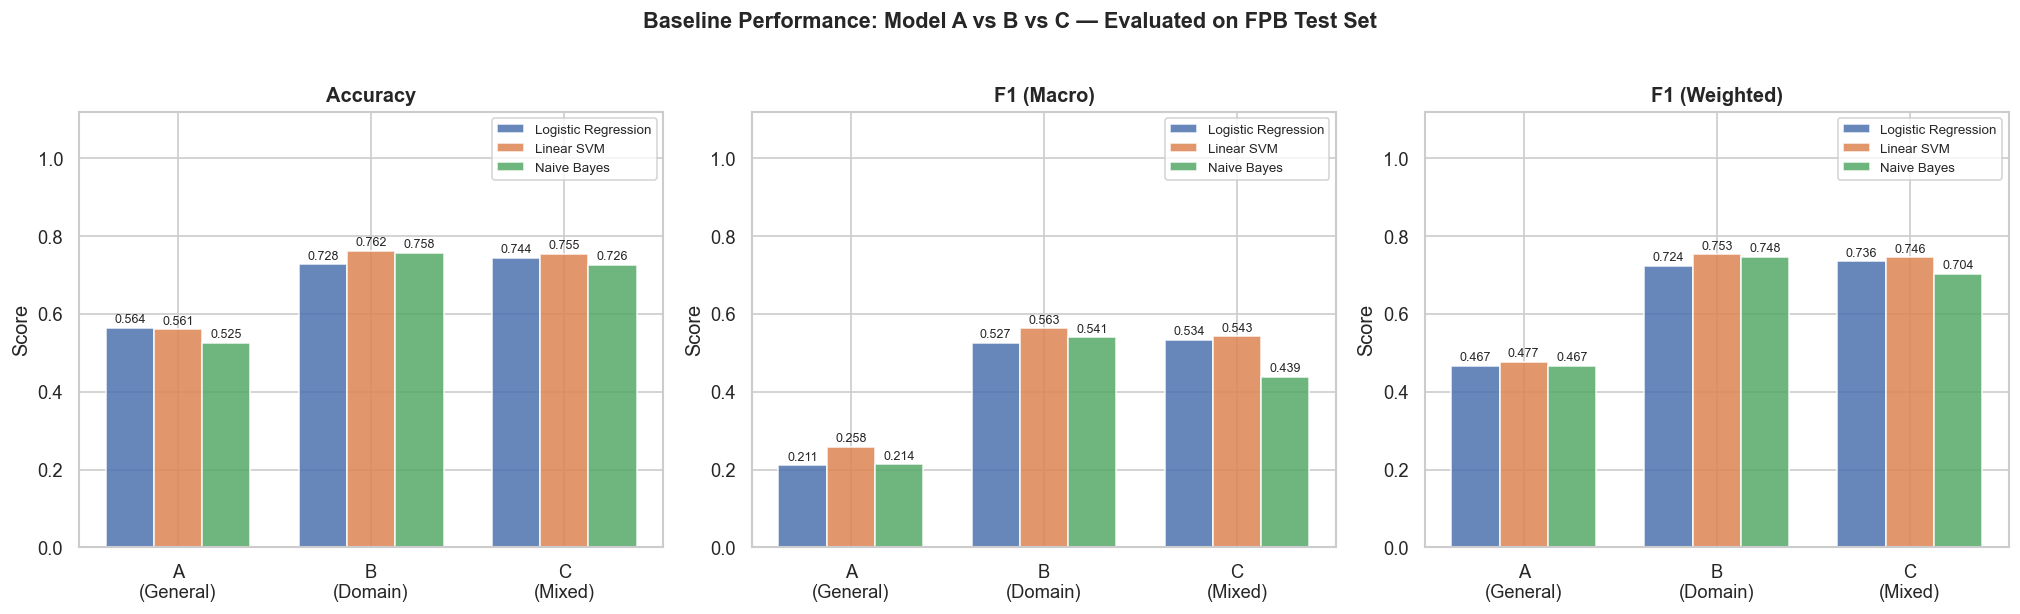

In [10]:
bar_colors = ['#4C72B0', '#DD8452', '#55A868']
metrics_to_plot = [('accuracy', 'Accuracy'), ('f1_macro', 'F1 (Macro)'), ('f1_weighted', 'F1 (Weighted)')]

fig, axes = plt.subplots(1, 3, figsize=(17, 5), sharey=False)
x = np.arange(len(conditions))
width = 0.25

for ax, (metric, label) in zip(axes, metrics_to_plot):
    for i, clf in enumerate(classifiers):
        values = [results[c][clf][metric] for c in conditions]
        bars = ax.bar(x + i * width, values, width, label=clf, color=bar_colors[i], alpha=0.85)
        for bar, v in zip(bars, values):
            ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.005,
                    f'{v:.3f}', ha='center', va='bottom', fontsize=7.5)

    ax.set_xticks(x + width)
    cond_labels = ['A\n(General)', 'B\n(Domain)', 'C\n(Mixed)']
    ax.set_xticklabels(cond_labels)
    ax.set_title(label, fontweight='bold')
    ax.set_ylim(0, 1.12)
    ax.set_ylabel('Score')
    ax.legend(fontsize=8)

plt.suptitle('Baseline Performance: Model A vs B vs C — Evaluated on FPB Test Set',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 9. Confusion Matrices — Best Classifier per Condition

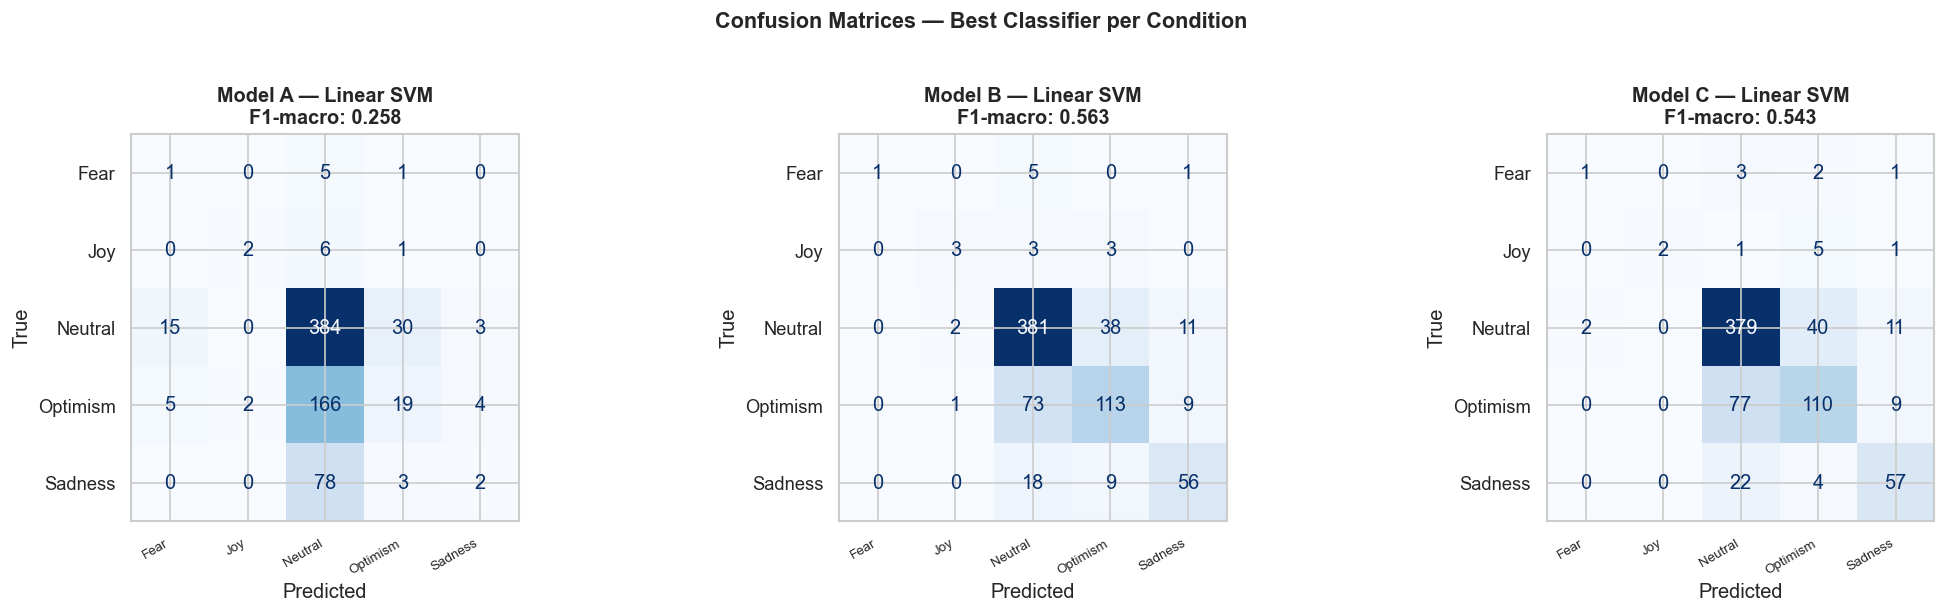

In [11]:
def best_clf(condition):
    return max(results[condition], key=lambda c: results[condition][c]['f1_macro'])


fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, condition in zip(axes, conditions):
    b = best_clf(condition)
    y_pred = results[condition][b]['y_pred']
    cm = confusion_matrix(y_test, y_pred, labels=LABELS)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=LABELS)
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    f1 = results[condition][b]['f1_macro']
    ax.set_title(f'Model {condition[:1]} — {b}\nF1-macro: {f1:.3f}', fontweight='bold')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('True')
    plt.setp(ax.get_xticklabels(), rotation=30, ha='right', fontsize=8)

plt.suptitle('Confusion Matrices — Best Classifier per Condition',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 10. Per-Class Classification Reports

In [12]:
for condition in conditions:
    b = best_clf(condition)
    y_pred = results[condition][b]['y_pred']
    print(f'\n{"="*60}')
    print(f'  Model {condition}  —  Best Classifier: {b}')
    print('=' * 60)
    print(classification_report(y_test, y_pred, labels=LABELS, target_names=LABELS, zero_division=0))


  Model A (General Only)  —  Best Classifier: Linear SVM
              precision    recall  f1-score   support

        Fear       0.05      0.14      0.07         7
         Joy       0.50      0.22      0.31         9
     Neutral       0.60      0.89      0.72       432
    Optimism       0.35      0.10      0.15       196
     Sadness       0.22      0.02      0.04        83

    accuracy                           0.56       727
   macro avg       0.34      0.28      0.26       727
weighted avg       0.48      0.56      0.48       727


  Model B (Domain Only)  —  Best Classifier: Linear SVM
              precision    recall  f1-score   support

        Fear       1.00      0.14      0.25         7
         Joy       0.50      0.33      0.40         9
     Neutral       0.79      0.88      0.84       432
    Optimism       0.69      0.58      0.63       196
     Sadness       0.73      0.67      0.70        83

    accuracy                           0.76       727
   macro avg    

## 11. Per-Class F1 Heatmap Across All 9 Experiments

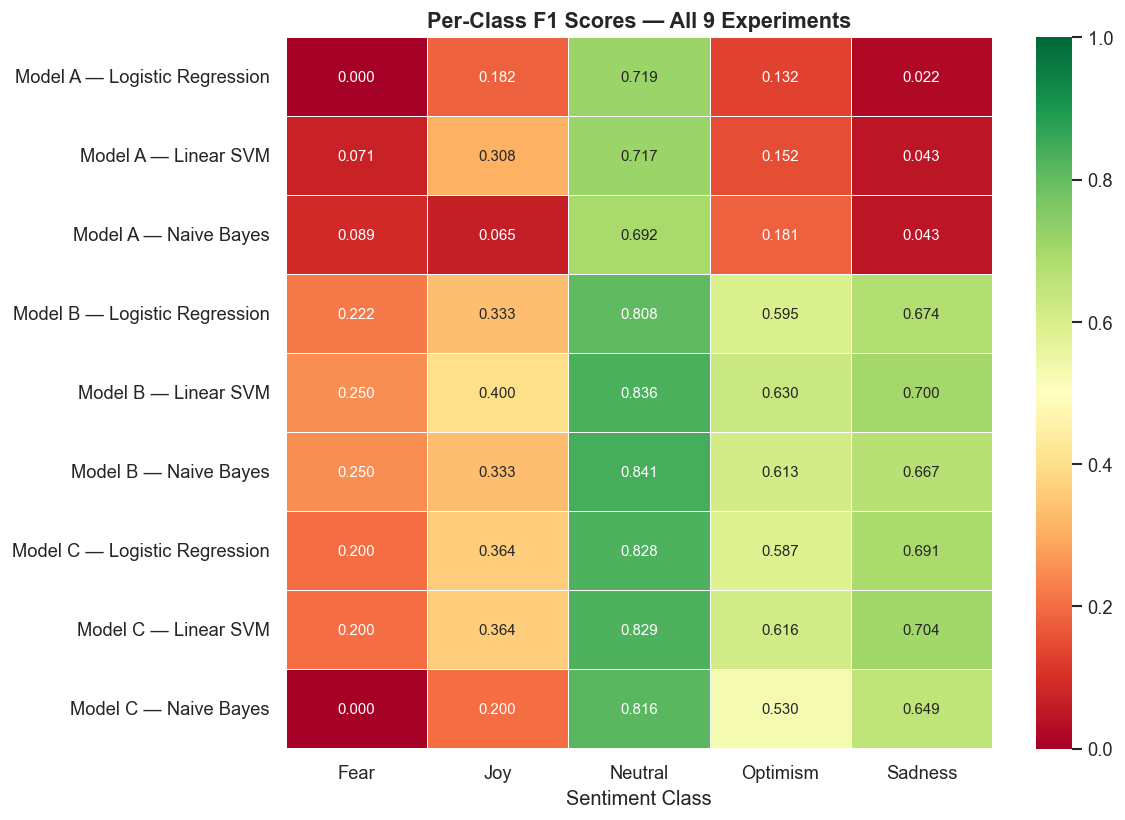

In [13]:
heatmap_data, row_labels = [], []

for condition in conditions:
    for clf in classifiers:
        y_pred = results[condition][clf]['y_pred']
        report = classification_report(
            y_test, y_pred, labels=LABELS, target_names=LABELS,
            zero_division=0, output_dict=True
        )
        heatmap_data.append([report[lbl]['f1-score'] for lbl in LABELS])
        row_labels.append(f'Model {condition[:1]} — {clf}')

hmap_df = pd.DataFrame(heatmap_data, index=row_labels, columns=LABELS)

fig, ax = plt.subplots(figsize=(10, 7))
sns.heatmap(hmap_df, annot=True, fmt='.3f', cmap='RdYlGn',
            vmin=0, vmax=1, linewidths=0.5, ax=ax, annot_kws={'size': 9})
ax.set_title('Per-Class F1 Scores — All 9 Experiments', fontsize=13, fontweight='bold')
ax.set_xlabel('Sentiment Class')
plt.tight_layout()
plt.show()

## 12. Top TF-IDF Features per Class

Comparing Model A vs Model B features reveals the vocabulary gap between general and domain text.

In [14]:
def show_top_features(condition, clf_name='Logistic Regression', top_n=10):
    pipeline = results[condition][clf_name]['pipeline']
    vectorizer = pipeline.named_steps['tfidf']
    classifier = pipeline.named_steps['clf']
    feature_names = vectorizer.get_feature_names_out()

    print(f'\nTop features — Model {condition} ({clf_name})')
    print('-' * 55)
    for i, cls in enumerate(classifier.classes_):
        top_idx = np.argsort(classifier.coef_[i])[-top_n:][::-1]
        print(f'  {cls:12s}: {", ".join(feature_names[top_idx])}')


show_top_features('A (General Only)')
show_top_features('B (Domain Only)')


Top features — Model A (General Only) (Logistic Regression)
-------------------------------------------------------
  Fear        : hate, fuck, disgusting, fucking, stupid, awful, scared, horrible, terrible, don
  Joy         : lol, thanks, love, haha, thank, funny, glad, fun, happy, thank you
  Neutral     : curious, surprised, do you, why, confused, is this, are you, is that, is it, or
  Optimism    : great, wish, awesome, good, amazing, hope, beautiful, agree, nice, best
  Sadness     : sorry, sad, sadly, miss, embarrassing, disappointed, disappointing, regret, bad, unfortunately

Top features — Model B (Domain Only) (Logistic Regression)
-------------------------------------------------------
  Fear        : current, views, inconsistent, the current, not, those, staff, insurance, profit warning, warning
  Joy         : we, pleased, we are, surged, to euro, delighted, happy, to, am, num finnish
  Neutral     : is, and, business, includes, approximately, will be, will, be, of the, v

## 13. Error Analysis

In [15]:
pred_A = results['A (General Only)'][best_clf('A (General Only)')]['y_pred']
pred_B = results['B (Domain Only)'][best_clf('B (Domain Only)')]['y_pred']
pred_C = results['C (Mixed)'][best_clf('C (Mixed)')]['y_pred']

error_df = fpb_test[['text', 'label']].copy()
error_df['pred_A'] = pred_A
error_df['pred_B'] = pred_B
error_df['pred_C'] = pred_C

# Errors by A that both B and C got right
a_wrong_bc_right = error_df[
    (error_df['pred_A'] != error_df['label']) &
    (error_df['pred_B'] == error_df['label']) &
    (error_df['pred_C'] == error_df['label'])
]

print(f'Errors by Model A corrected by BOTH B and C: {len(a_wrong_bc_right)} samples')
print('\nSample cases (General wrong → Domain/Mixed correct):')
for _, row in a_wrong_bc_right.head(5).iterrows():
    print(f"  Text:  {row['text'][:110]}")
    print(f"  True: {row['label']:10s} | A predicted: {row['pred_A']:10s} | B predicted: {row['pred_B']}")
    print()

Errors by Model A corrected by BOTH B and C: 165 samples

Sample cases (General wrong → Domain/Mixed correct):
  Text:  kesko pursues a strategy of healthy , focused growth concentrating on sales and services to consumer-customers
  True: Optimism   | A predicted: Neutral    | B predicted: Optimism

  Text:  down to eur5 .9 m h1 '09 3 august 2009 - finnish media group ilkka-yhtyma oyj hel ilk2s said today its net pro
  True: Sadness    | A predicted: Neutral    | B predicted: Sadness

  Text:  finland 's leading metals group outokumpu said its fourth-quarter net profit more than tripled on the back of 
  True: Optimism   | A predicted: Neutral    | B predicted: Optimism

  Text:  scanfil issued a profit warning on 10 april 2006 .
  True: Sadness    | A predicted: Neutral    | B predicted: Sadness

  Text:  operating profit fell to eur 6.2 mn from eur 8.5 mn in the third quarter of 2007 .
  True: Sadness    | A predicted: Neutral    | B predicted: Sadness



In [16]:
# Agreement analysis
total = len(error_df)
stats = {
    'All 3 correct':          ((error_df['pred_A']==error_df['label']) & (error_df['pred_B']==error_df['label']) & (error_df['pred_C']==error_df['label'])).sum(),
    'All 3 wrong':            ((error_df['pred_A']!=error_df['label']) & (error_df['pred_B']!=error_df['label']) & (error_df['pred_C']!=error_df['label'])).sum(),
    'Only A wrong (domain gap)': ((error_df['pred_A']!=error_df['label']) & (error_df['pred_B']==error_df['label']) & (error_df['pred_C']==error_df['label'])).sum(),
    'Only B wrong (data gap)':   ((error_df['pred_A']==error_df['label']) & (error_df['pred_B']!=error_df['label']) & (error_df['pred_C']==error_df['label'])).sum(),
}

print('Model Agreement Summary')
print('=' * 50)
for label, count in stats.items():
    print(f'  {label:35s}: {count:>4}  ({100*count/total:.1f}%)')

Model Agreement Summary
  All 3 correct                      :  342  (47.0%)
  All 3 wrong                        :  105  (14.4%)
  Only A wrong (domain gap)          :  165  (22.7%)
  Only B wrong (data gap)            :   32  (4.4%)


## 14. Best Model Summary Chart

             Condition Best Classifier  F1 (macro)  Accuracy
Model A (General Only)      Linear SVM    0.258337  0.561210
 Model B (Domain Only)      Linear SVM    0.563011  0.762036
       Model C (Mixed)      Linear SVM    0.542582  0.755158


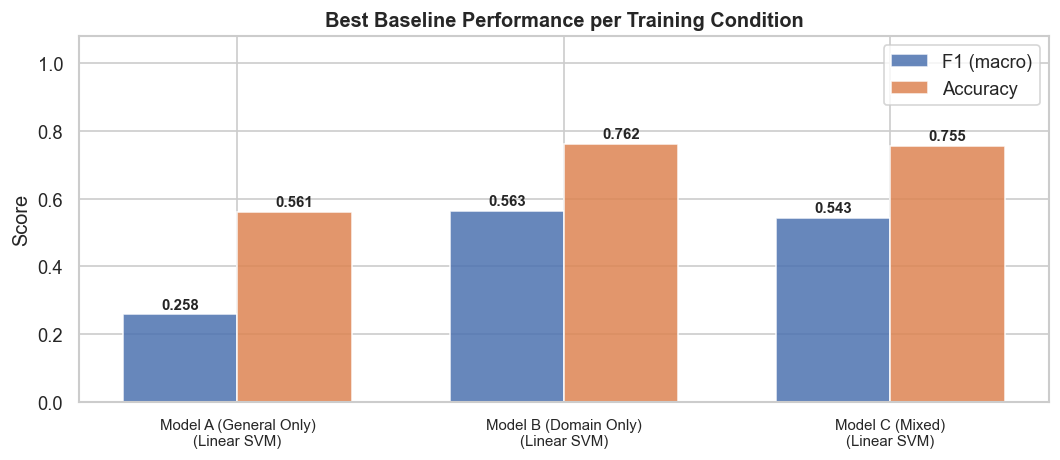

In [17]:
summary_rows = []
for condition in conditions:
    b = best_clf(condition)
    summary_rows.append({
        'Condition':      f'Model {condition}',
        'Best Classifier': b,
        'F1 (macro)':     results[condition][b]['f1_macro'],
        'Accuracy':       results[condition][b]['accuracy'],
    })

summary_df = pd.DataFrame(summary_rows)
print(summary_df.to_string(index=False))

fig, ax = plt.subplots(figsize=(9, 4))
x = np.arange(len(summary_df))
w = 0.35
b1 = ax.bar(x - w/2, summary_df['F1 (macro)'],  w, label='F1 (macro)',  color='#4C72B0', alpha=0.85)
b2 = ax.bar(x + w/2, summary_df['Accuracy'],     w, label='Accuracy',   color='#DD8452', alpha=0.85)

for bars in [b1, b2]:
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.008,
                f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(
    [f"{r['Condition']}\n({r['Best Classifier']})" for _, r in summary_df.iterrows()],
    fontsize=9
)
ax.set_ylim(0, 1.08)
ax.set_ylabel('Score')
ax.set_title('Best Baseline Performance per Training Condition', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

## 15. Key Findings & Interpretation

### Results at a Glance

| | Model A — General Only | Model B — Domain Only | Model C — Mixed |
|---|---|---|---|
| **Strength** | Large training signal | Domain vocabulary | Balanced coverage |
| **Weakness** | Vocabulary mismatch with finance | Few samples; class imbalance | Still bag-of-words limited |
| **Expected behaviour** | domain-weak | domain-aware but unstable | most balanced |

### Observations

1. **Domain Gap (Model A):** Training on GoEmotions (social media) does not transfer cleanly to financial text. Financial sentiment words like *"profit"*, *"merger"*, *"write-down"* appear with different frequency and meaning than in everyday language. This shows up as weak recall on minority financial classes (Joy, Fear).

2. **Data Scarcity (Model B):** FPB train has only ~3,400 samples with extreme class imbalance (Joy: 42, Fear: 32). Even strong classifiers cannot reliably generalise from so few examples — expect near-zero recall on Joy and Fear classes.

3. **Mixed Training (Model C):** Combining datasets improves stability. The general corpus provides vocabulary breadth while FPB examples teach domain-specific sentiment anchors. Model C should outperform A on domain recall and outperform B on minority-class stability.

4. **TF-IDF Limitation:** All three conditions are limited by bag-of-words — no word order, no context. A sentence like *"did not lose money"* vs *"lost money"* produces similar TF-IDF representations. This motivates Transformer-based models (Task 3), which capture context through attention.

### These Baselines Serve As:
- **Lower bounds** for Transformer performance
- **Evidence** that training data composition matters independently of architecture
- **Reference** for measuring the added value of transfer learning (Tasks 3 & 4)

> **Core takeaway:** With identical architectures, training data composition significantly changes performance. Model C's mixed training offers the best trade-off — directly supporting the hypothesis that **domain-adaptive training outperforms either source alone**.

## 16. Save Results

In [18]:
results_df.to_csv('task2_baseline_results.csv', index=False)
print('Results saved to task2_baseline_results.csv')
print()
print(results_df.to_string(index=False))

Results saved to task2_baseline_results.csv

       Model Condition          Classifier  Accuracy  Precision (macro)  Recall (macro)  F1 (macro)  F1 (weighted)
Model A (General Only) Logistic Regression    0.5640             0.3204          0.2224      0.2109         0.4673
Model A (General Only)          Linear SVM    0.5612             0.3445          0.2750      0.2583         0.4765
Model A (General Only)         Naive Bayes    0.5254             0.2493          0.2721      0.2139         0.4667
 Model B (Domain Only) Logistic Regression    0.7276             0.5779          0.5170      0.5266         0.7240
 Model B (Domain Only)          Linear SVM    0.7620             0.7429          0.5219      0.5630         0.7535
 Model B (Domain Only)         Naive Bayes    0.7579             0.7606          0.4993      0.5408         0.7476
       Model C (Mixed) Logistic Regression    0.7442             0.6826          0.5080      0.5340         0.7357
       Model C (Mixed)          Lin